In [1]:
import os

os.chdir("..")
print(os.getcwd())

import sys
from pathlib import Path
from importlib import reload

import utils.paths as paths
import numpy as np

/hs/fs08/data/group-brueggen/tmartinez/diffusion/src


# Evaluate Dataset

In [7]:
import data.sets.prototypes_webdataset

reload(data.sets.prototypes_webdataset)
from data.sets.prototypes_webdataset import PrototypesDataset

output_tuple = (
    "__key__",
    "model.npy",
    "model_beam.npy",
    "mask.npy",
    "mask_size.npy",
    "circle_radius.npy",
)

dset = PrototypesDataset(
    "model-prototypes",
    output_tuple=output_tuple,
    resampled=False,
    load_catalog=True,
    image_size=256,
    transform="EvalTransformPrototypesWDS",
    count=True,
)

from torch.utils.data import DataLoader

batch_size = 25
dl = DataLoader(
    dset,
    batch_size=batch_size,
    num_workers=16,
    drop_last=False,
)

10:23:39 - INFO (PrototypesDataset): Loading dataset from 
	</hs/fs08/data/group-brueggen/tmartinez/image_data/LOFAR/model_prototypes/model_prototypes/images.tar>.
10:23:39 - INFO (PrototypesDataset): Counting samples in the dataset...
10:24:29 - INFO (PrototypesDataset): Dataset length: 132_587          
10:24:29 - INFO (PrototypesDataset): Loading catalog...
10:24:30 - INFO (PrototypesDataset): Data set initialized.


## Plot Images

In [8]:
key, x, xbeam, mask, mask_size, circle_radius = next(iter(dl))
source_names = tuple(k.replace('p', '.') for k in key)

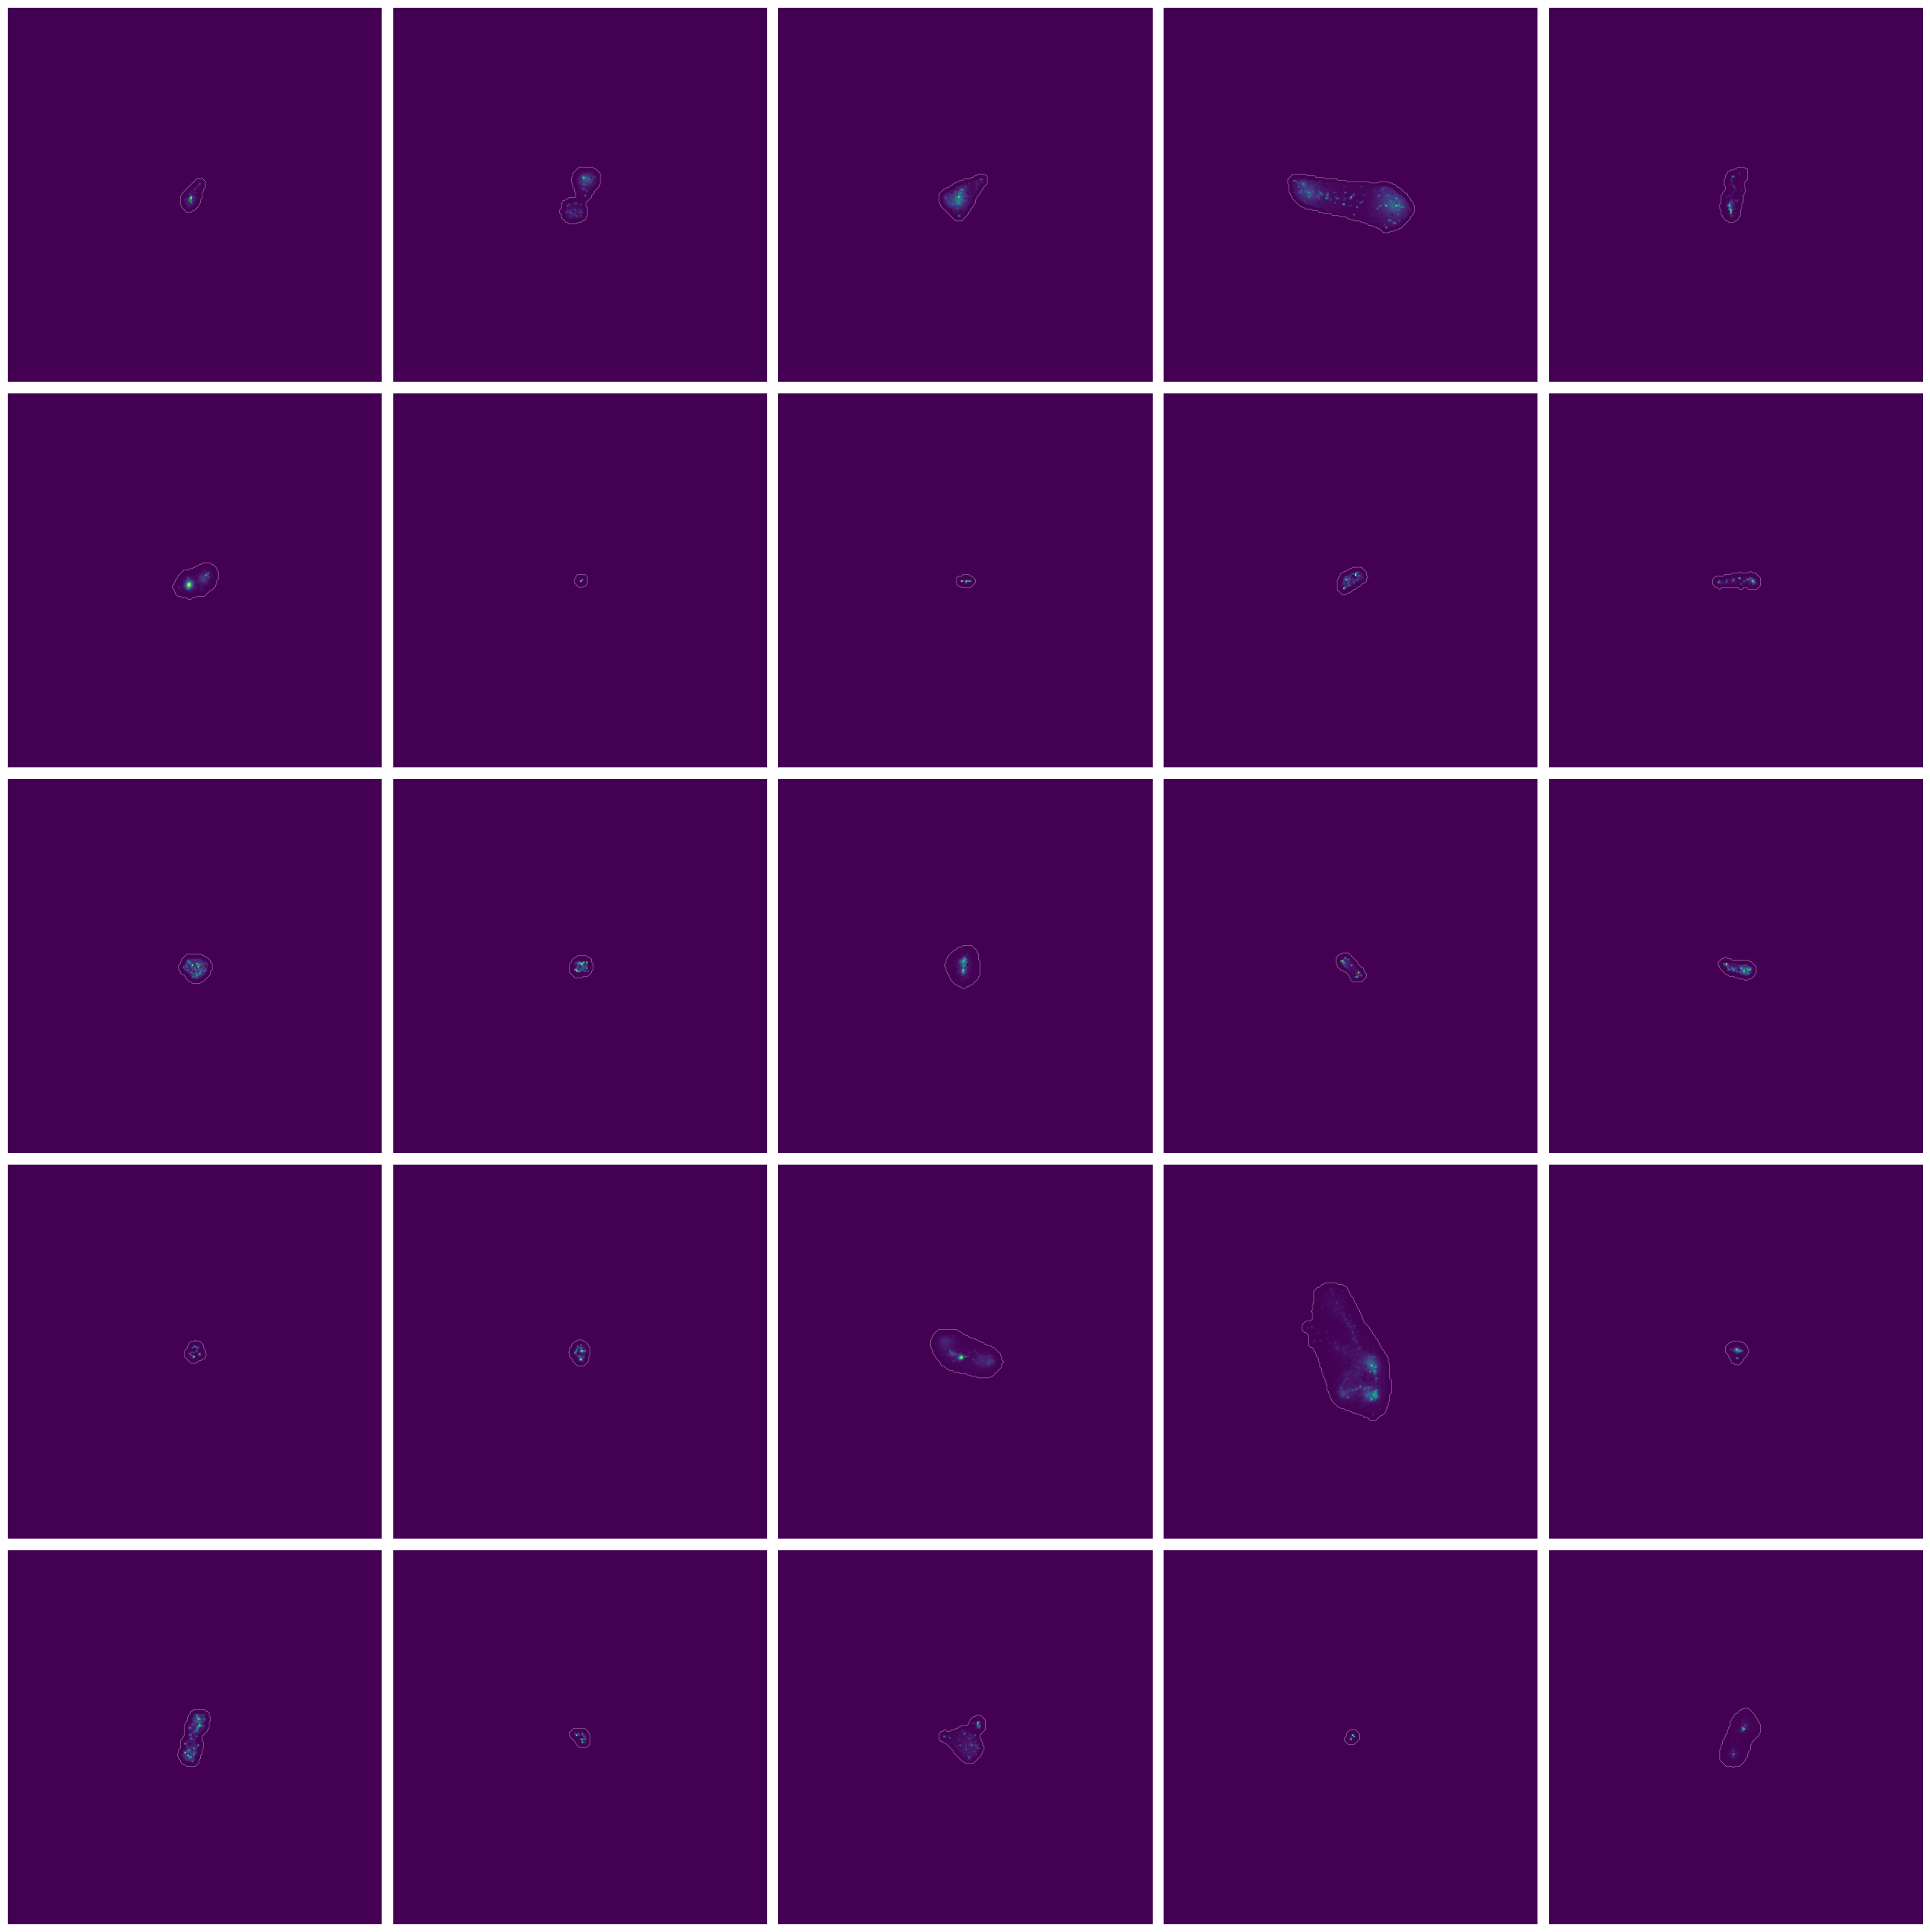

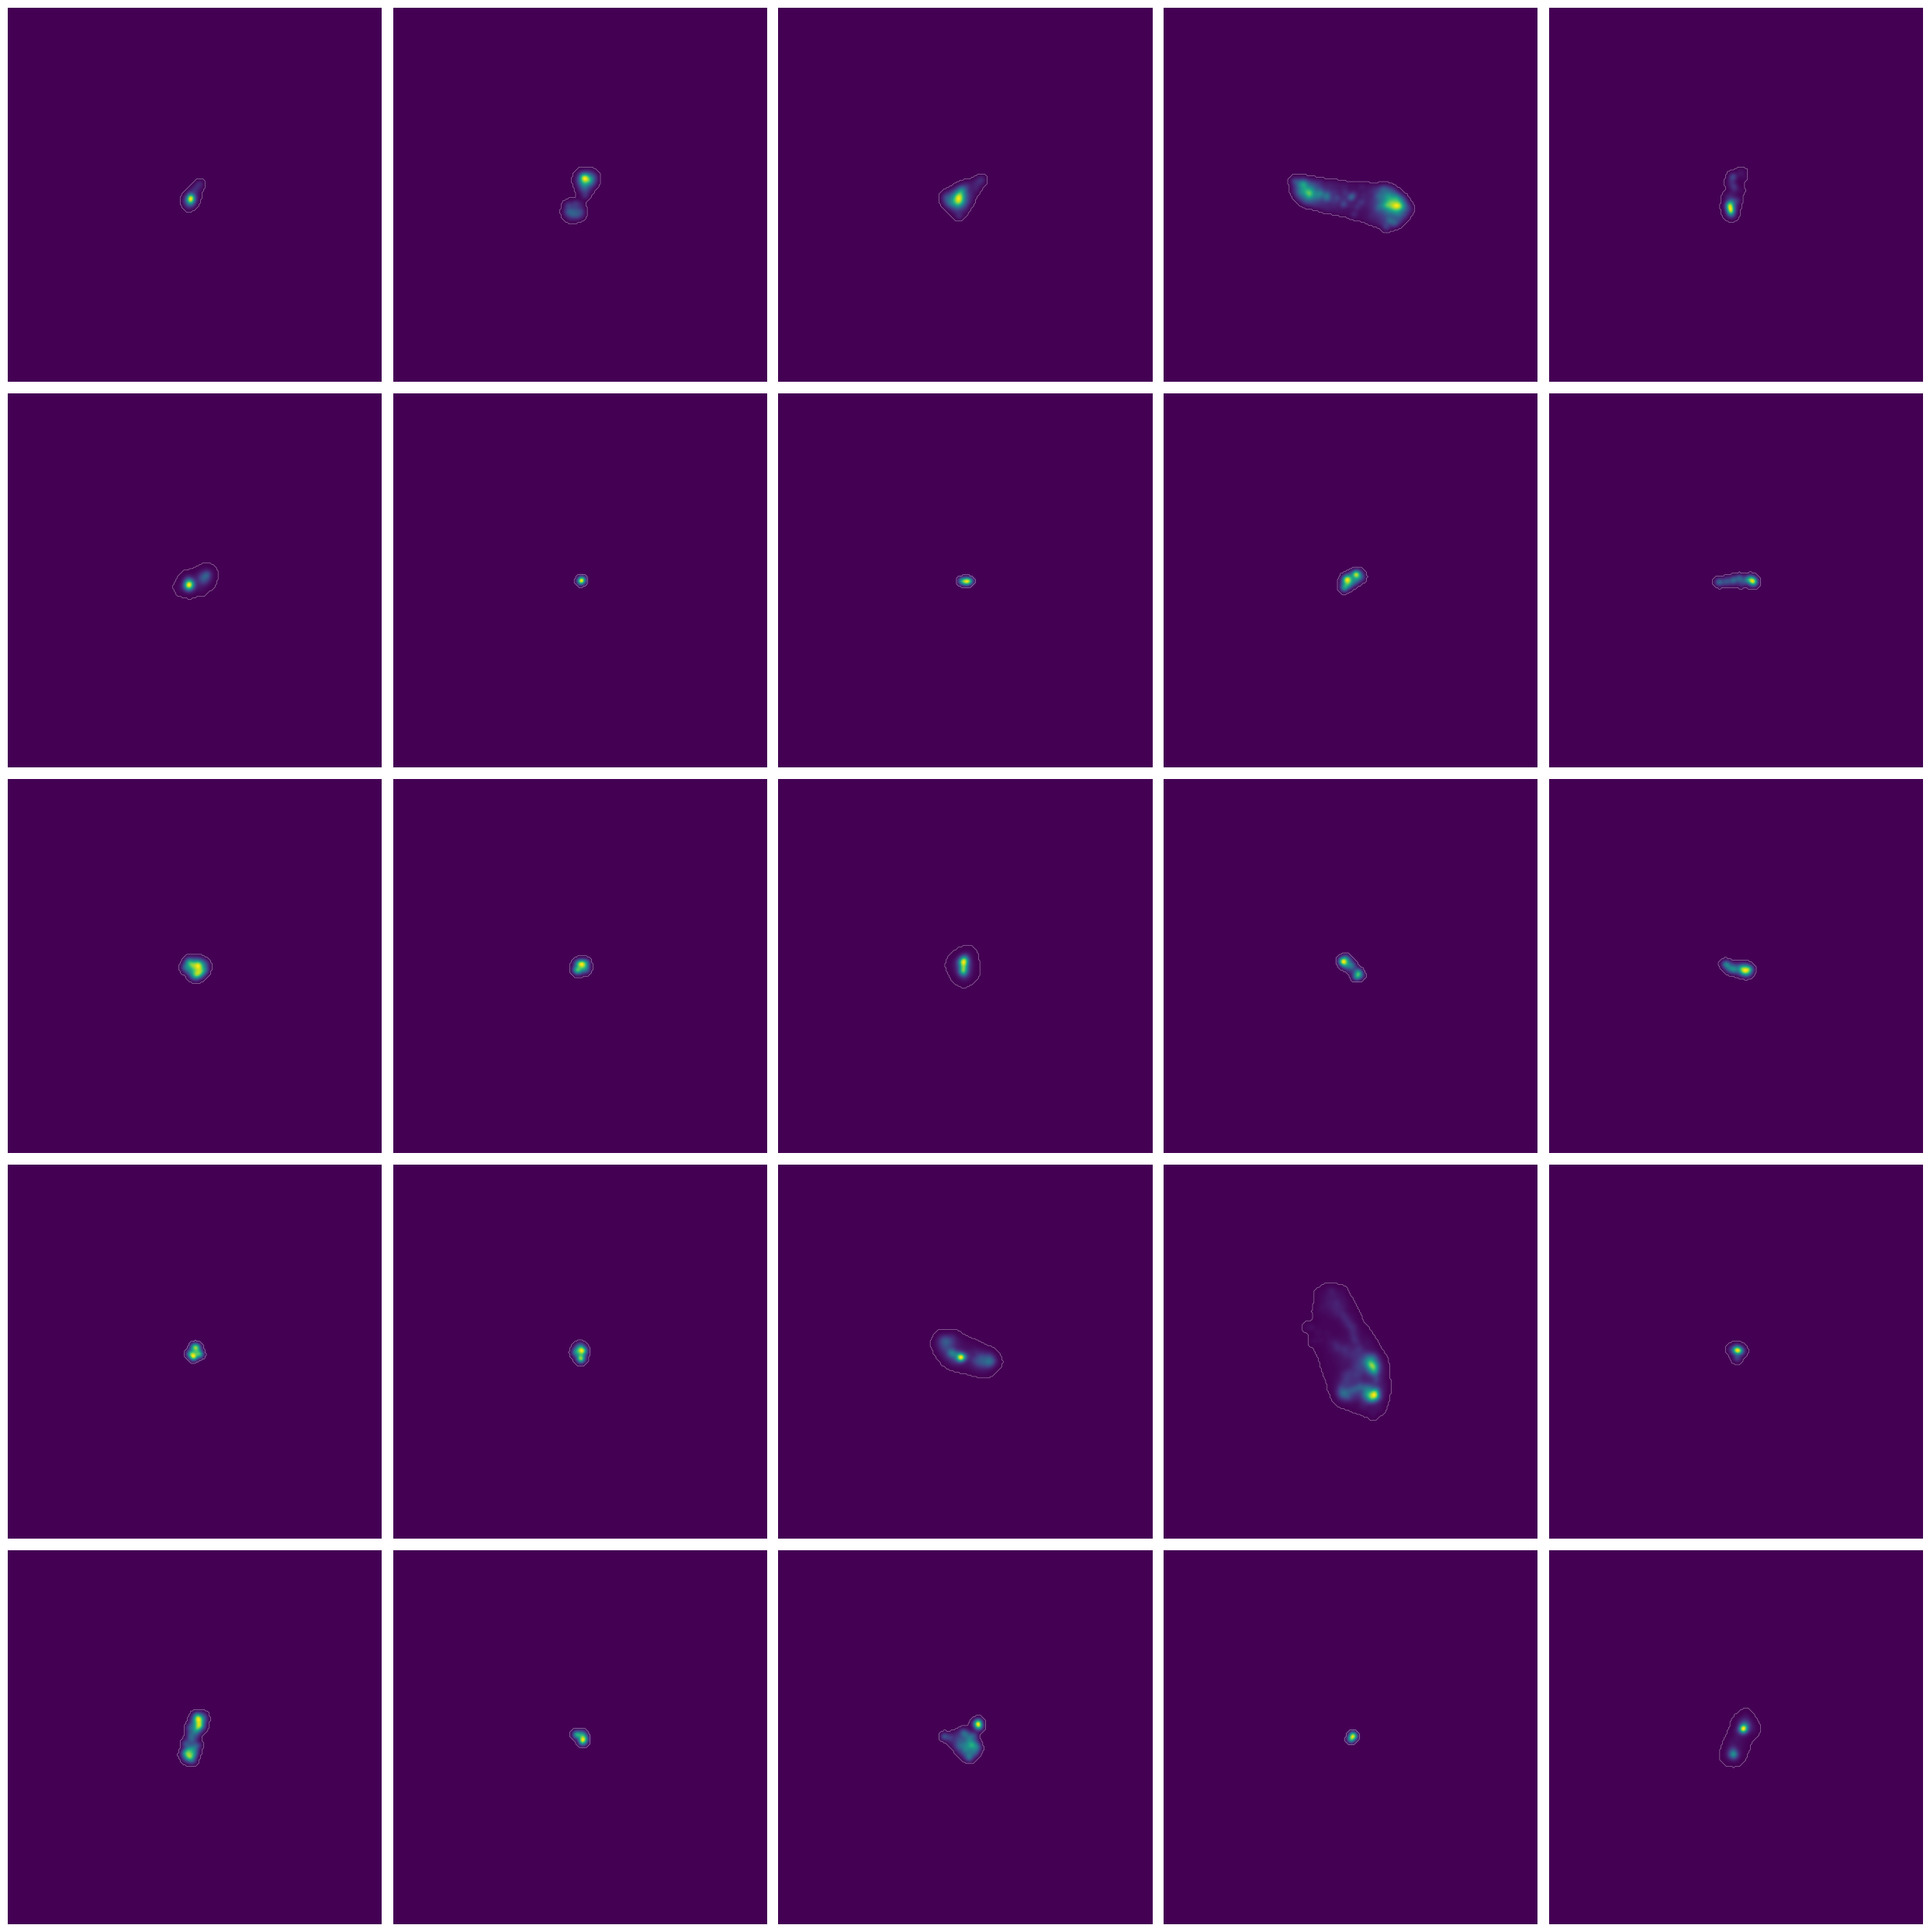

In [9]:
from plotting.image_plots import plot_image_grid

_ = plot_image_grid(x, masks=mask)
_ = plot_image_grid(xbeam, masks=mask)

## Subsets

In [ ]:
subset = dset.select(lambda sample: sample[4] > 250)
sub_dl = DataLoader(subset, batch_size=25, num_workers=1, drop_last=False)

In [31]:
key, x, x_beam, mask, mask_size, circle_radius = next(iter(sub_dl))
source_names = tuple(k.replace('p', '.') for k in key)

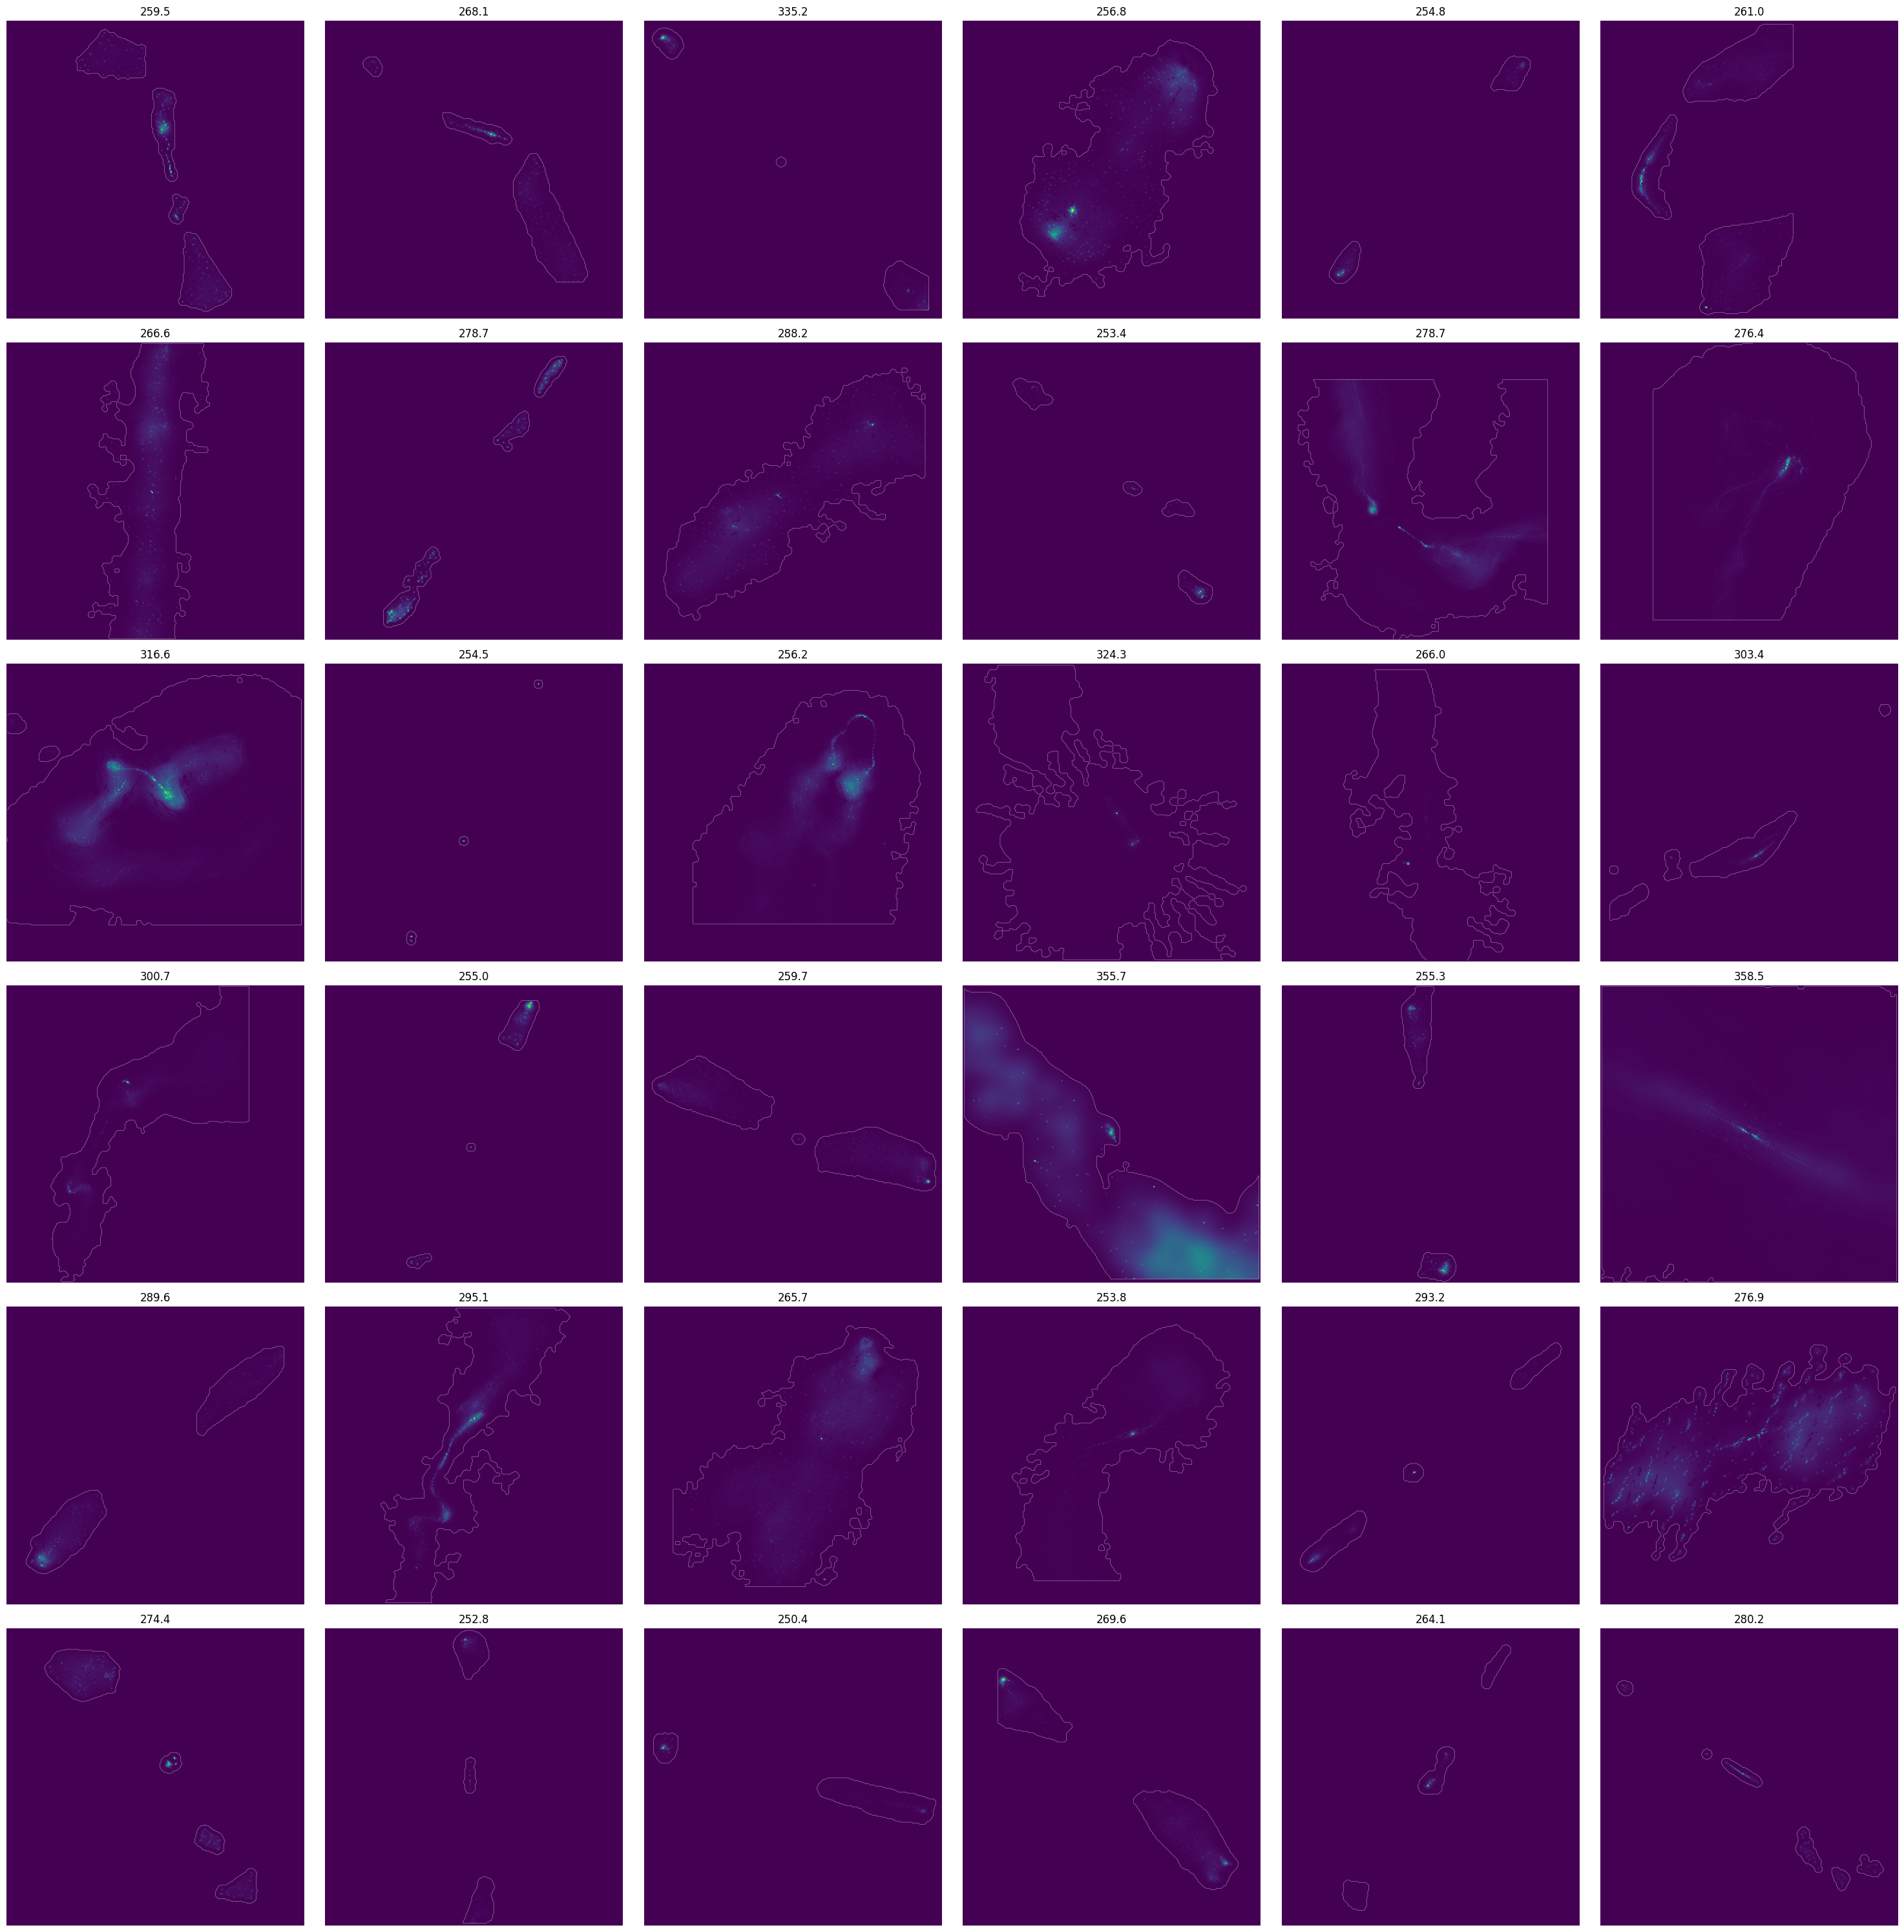

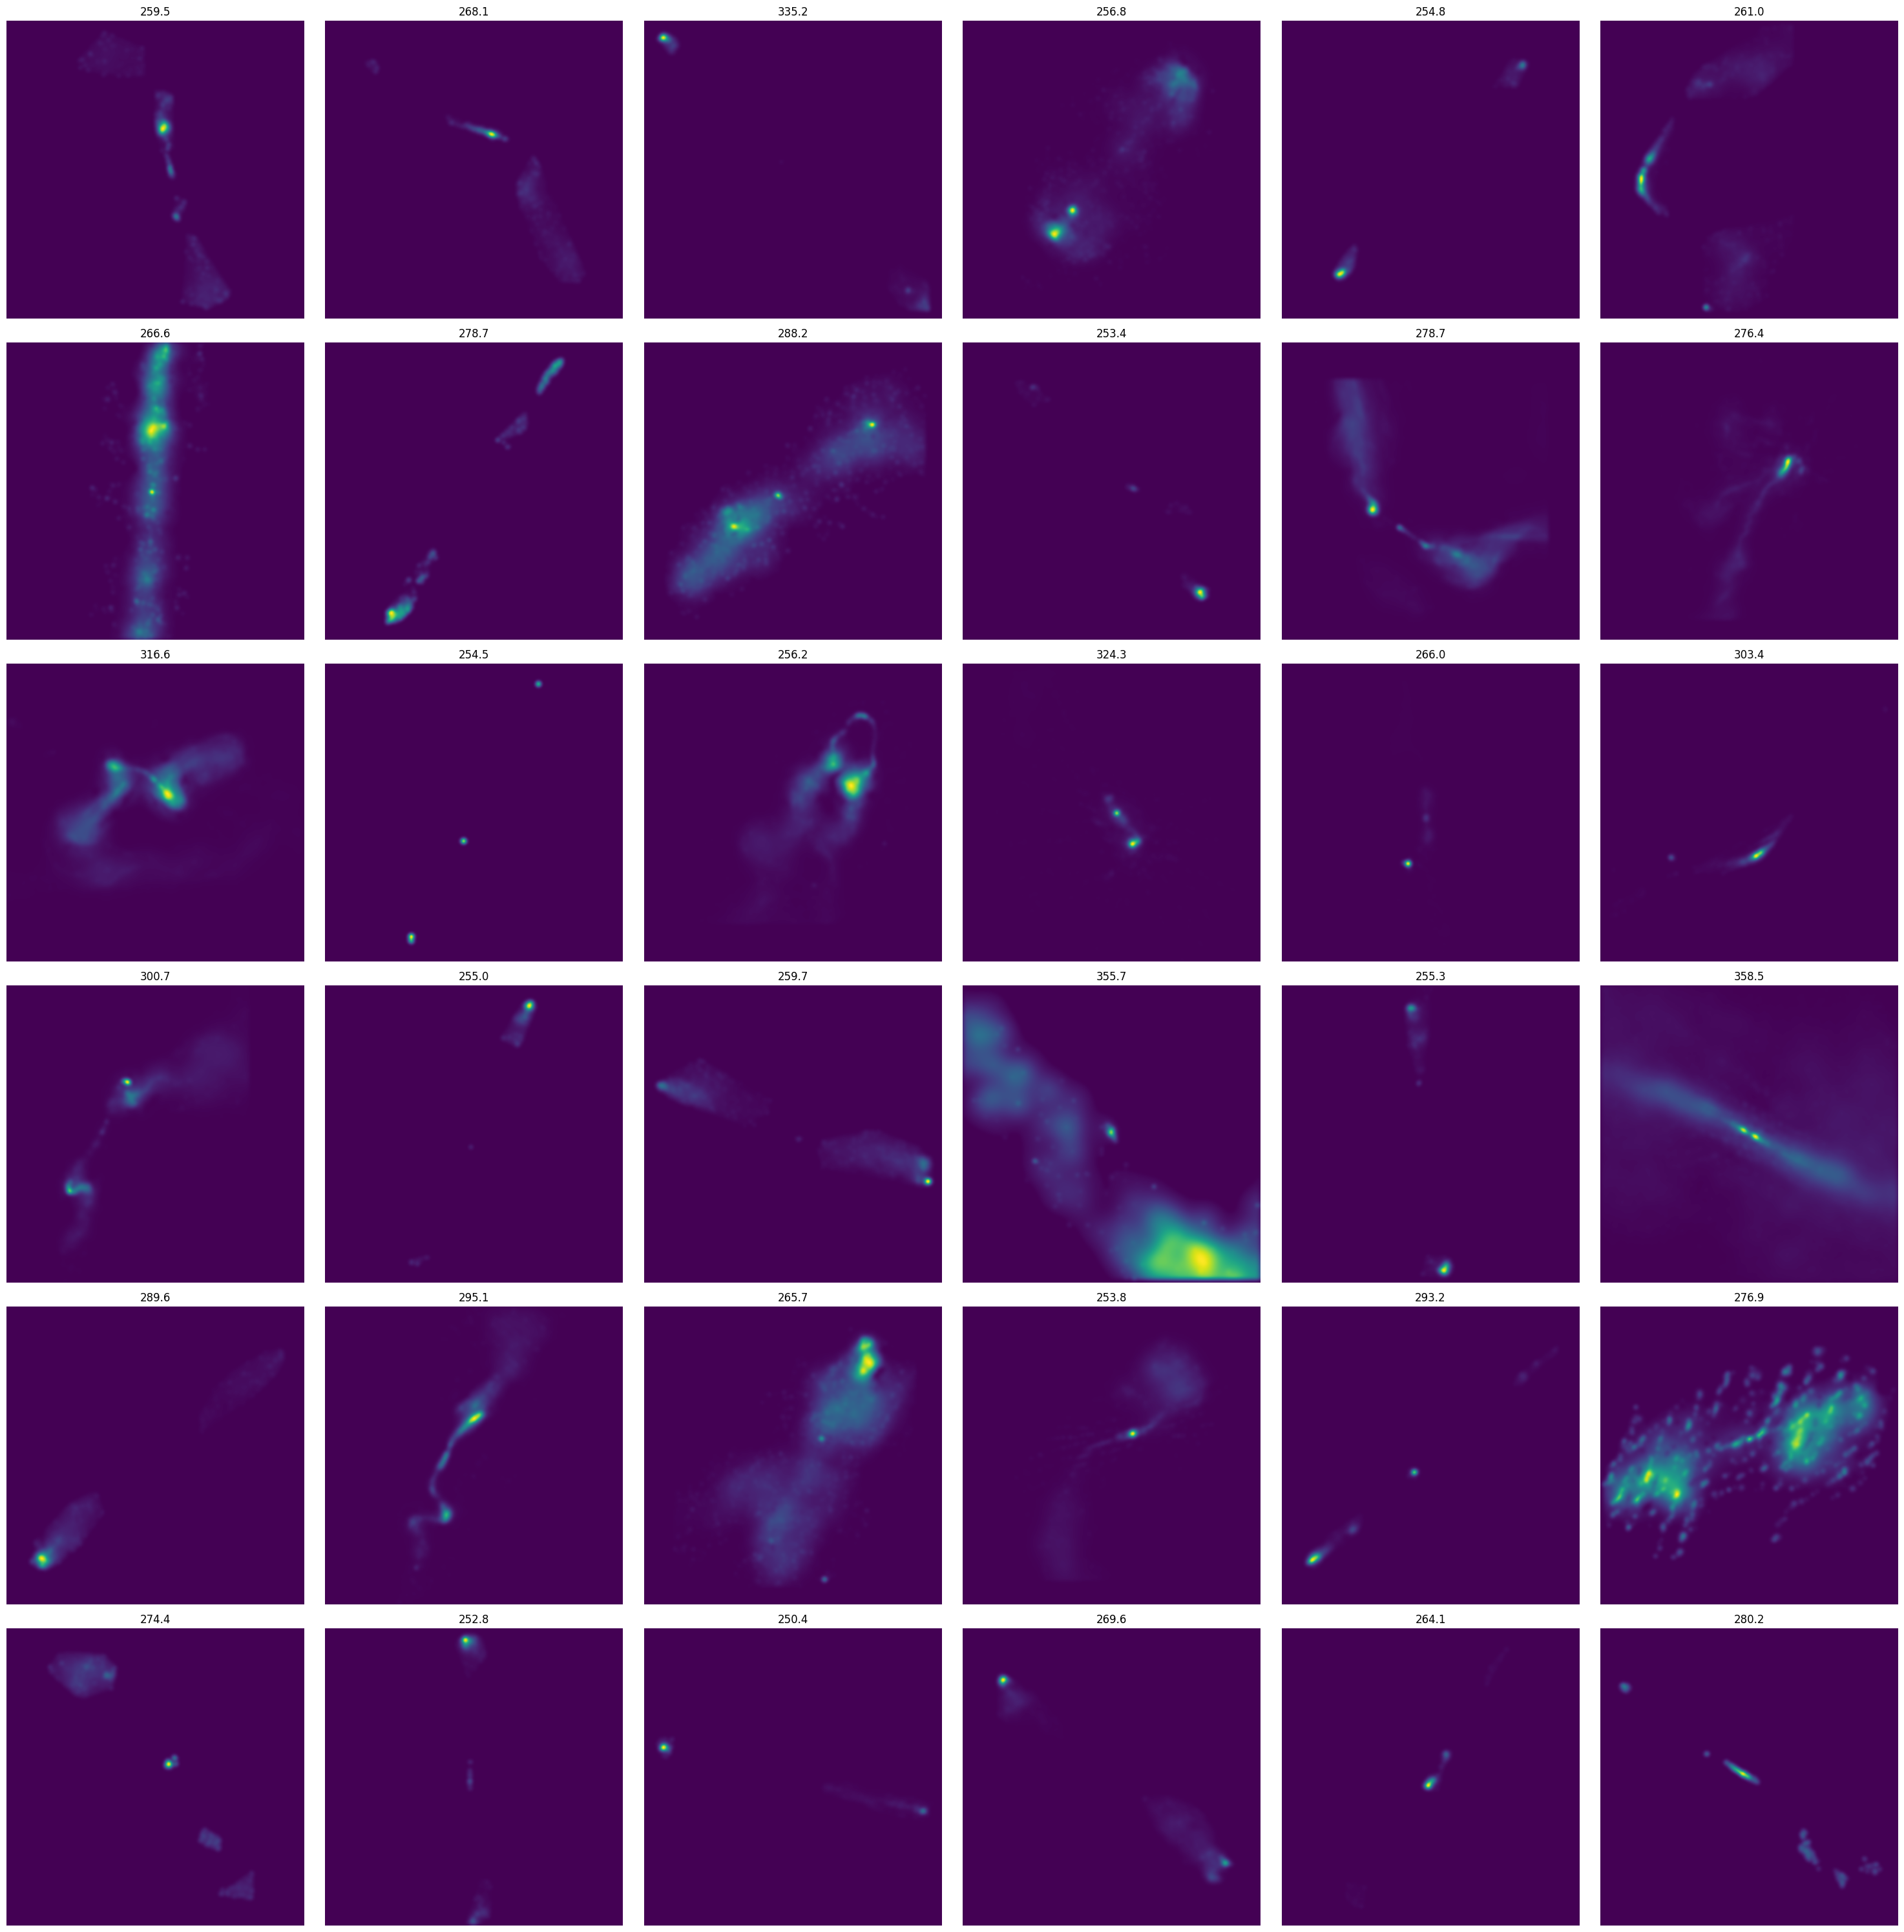

In [36]:
from plotting.image_plots import plot_image_grid

titles = [f"{s.item():.1f}" for s in mask_size]
_ = plot_image_grid(x, masks=mask, titles=titles)
_ = plot_image_grid(x_beam, titles=titles)

In [ ]:
from data.trf.image_utils import apply_restoring_beam

x_rest = apply_restoring_beam(x)

plot_image_grid(x_rest)

## Plot Histograms

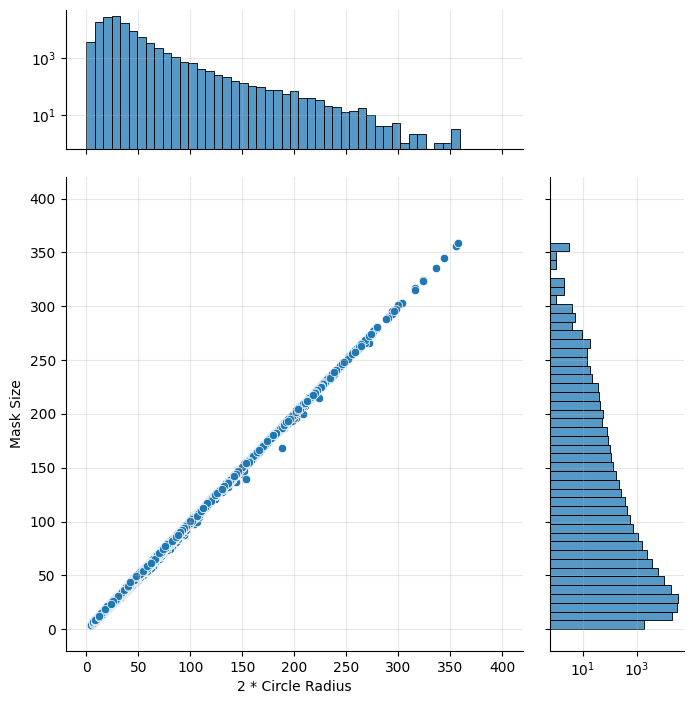

In [23]:
import seaborn as sns

radius = dset.cat.pt_circle_radius.values
size = dset.cat.pt_mask_size.values

marginal_kws = dict(bins=np.linspace(0, 400, 50), log=True)
p = sns.jointplot(x=2*radius, y=size, kind="scatter", height=7, ratio=3, marginal_kws=marginal_kws, marginal_ticks=True)
p.set_axis_labels("2 * Circle Radius", "Mask Size")

for ax in [p.ax_marg_x, p.ax_marg_y, p.ax_joint]:
    ax.grid(alpha=0.3)



In [50]:
np.array([0] + (2**np.arange(5)).tolist())

array([ 0,  1,  2,  4,  8, 16])

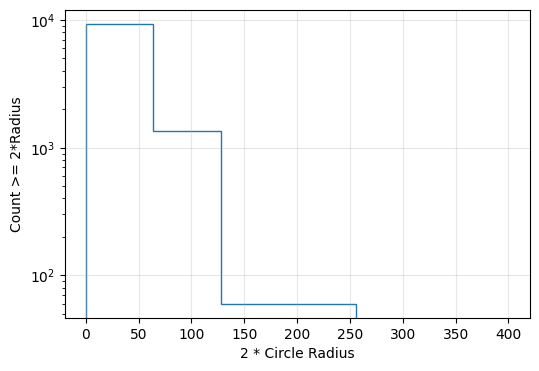

In [55]:
# Cumulative histogram of mask radii
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6,4))
cts, bins = np.histogram(2*radius, bins=np.array([0, 64, 128, 256, 400]))
cts_cum = np.cumsum(cts)
ax.stairs(cts_cum[-1] - cts_cum, bins)
ax.set_xlabel("2 * Circle Radius")
ax.set_ylabel("Count >= 2*Radius")
ax.grid(alpha=0.3)
ax.set_yscale('log')

fig.show()

In [60]:
bins, cts, cts_cum, cts_cum[-1] - cts_cum

(array([  0,  64, 128, 256, 400]),
 array([123242,   8003,   1282,     60]),
 array([123242, 131245, 132527, 132587]),
 array([9345, 1342,   60,    0]))

In [62]:
(2*radius >= 128).sum()

1342

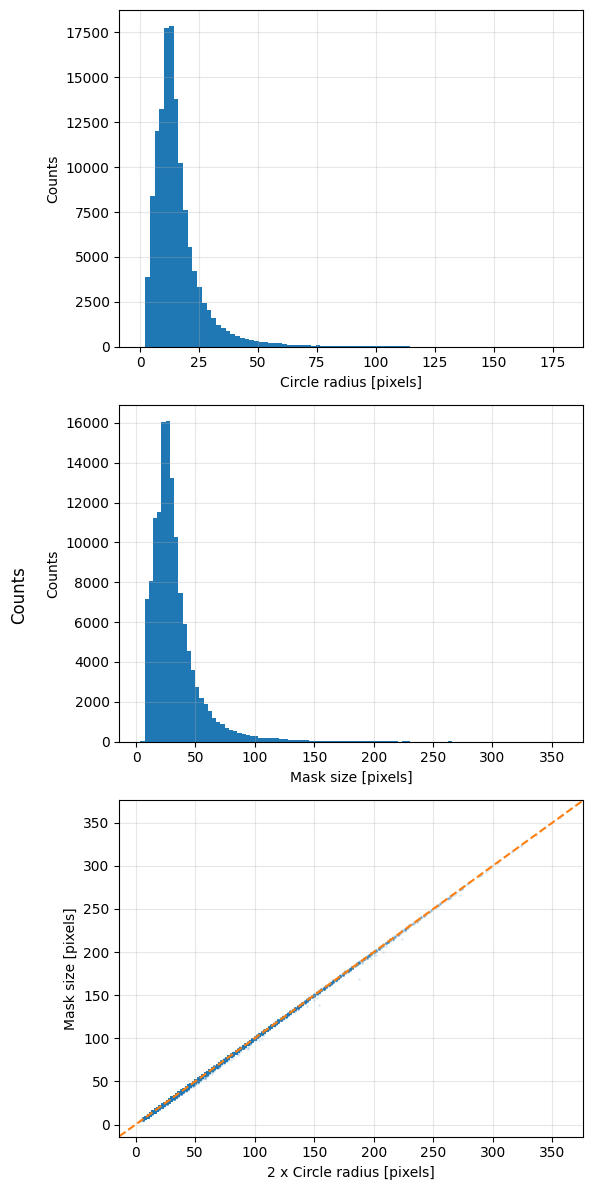

In [10]:
import matplotlib.pyplot as plt

radius = dset.cat.pt_circle_radius.values
size = dset.cat.pt_mask_size.values

fig, axs = plt.subplots(3, 1, figsize=(6, 12), tight_layout=True)

ax = axs[0]
ax.hist(
    radius,
    bins=np.linspace(0, mx := int(np.ceil(max(radius))), mx // 2 + 1),
    density=False,
)
ax.set_xlabel("Circle radius [pixels]")
ax.set_ylabel("Counts")

ax = axs[1]
ax.hist(size, bins=100, density=False)
ax.set_xlabel("Mask size [pixels]")
ax.set_ylabel("Counts")

ax = axs[2]
ax.scatter(2 * radius, size, s=1, alpha=0.1)
med = (np.median(radius) + np.median(size)) / 2
ax.axline((med, med), slope=1, color="C1", linestyle="--", label="y=x")
ax.set_xlabel("2 x Circle radius [pixels]")
ax.set_ylabel("Mask size [pixels]")

fig.supylabel("Counts")

for ax in axs.flatten():
    ax.grid(alpha=0.3)
    # ax.set_yscale('log')

fig.show()

# Selection Procedure

## Imports and definitions:

These are all the functions we need:

Import DR2 resolved sources and component catalogs: <br>
(used for source identification and association)

In [ ]:
from data.data_utils import load_lotss_catalog

print("Loading resolved sources catalog...")
res_cat = load_lotss_catalog(path=paths.LOFAR_RES_CAT, select_cols=None)

print("Loading component catalog...")
cmp_cat = load_lotss_catalog(
    paths.LOFAR_DATA_PARENT / "combined-components-v1.1.fits",
    select_cols=["Component_Name", "RA", "DEC", "Parent_Source"],
)

Filter the catalog for pointings that have an existing model image:

Make subset selection of sources:

In [ ]:
from tqdm import tqdm

# Filter for pointings that have valid model data
pointing_parent = paths.LOFAR_DATA_PARENT / "pointings"
all_pointings = sorted(list(pointing_parent.glob("*")))
print(f"Total pointings found: {len(all_pointings)}")

flag_dict = {
    p.name: (p / "images").exists()
    for p in tqdm(all_pointings, desc="Checking pointings")
}
flag = np.array(
    [flag_dict[m] for m in tqdm(res_cat["Mosaic_ID"], desc="Checking flags")]
)
res_cat = res_cat[flag].reset_index(drop=True)
print(f"Catalog filtered to {len(res_cat)} sources with valid model data.")

# Pre-selection based on SNR
SNR_tot = res_cat.Total_flux / res_cat.E_Total_flux
filter_flag = SNR_tot.values >= 5

# Pick random sources from catalog
n_src = 10000
rand_inds = np.random.choice(np.argwhere(filter_flag).flatten(), n_src, replace=False)
rand_inds.sort()

# Random sources
sub_cat = res_cat.iloc[rand_inds]

- Get the model cutouts for the selected images
- Apply restoring beam

In [ ]:
import concurrent.futures
from functools import partial
from data.obs.cutouts import cutout_from_catalog
from tqdm import tqdm, trange
from data.trf.image_utils import apply_restoring_beam


def extract_cutout(i, catalog, **kwargs):
    """Extract a single cutout - wrapper for parallel execution"""
    return cutout_from_catalog(catalog, i, **kwargs)[0]


# Prepare the partial function with fixed arguments
kw = dict(mask_nan=False, size_px=256, opt_c=True)

# For model cuts
extract_model = partial(
    extract_cutout,
    catalog=sub_cat,
    parent_dir=paths.LOFAR_DATA_PARENT / "pointings",
    file_name="images/image_full_ampphase_di_m.NS.int.model.fits",
    **kw,
)

# Run model cutouts in parallel
print("Extracting model cutouts in parallel...")
with concurrent.futures.ThreadPoolExecutor(max_workers=32) as executor:
    model_cuts = list(
        tqdm(
            executor.map(extract_model, range(n_src)), total=n_src, desc="Model cutouts"
        )
    )

model_cuts = np.clip(np.array(model_cuts), 0, None)
model_cuts_beam = apply_restoring_beam(model_cuts)

print(f"Extracted {len(model_cuts)} model cutouts")
print(f"Shape: {model_cuts.shape}")

Make Masks:

In [ ]:
from data.trf.segment import smooth_mask, refine_mask

masks = model_cuts_beam > 5e-5
masks = np.array([smooth_mask(mask) for mask in tqdm(masks)])

Make source association:

In [ ]:
from data.obs.prototypes_utils import source_profile, make_clean_mask

profiles = []
clean_masks = np.empty_like(masks)

# Loop through all selected images
for i in tqdm(range(n_src)):

    clean_mask, profile = make_clean_mask(masks[i], sub_cat.iloc[i], cmp_cat=cmp_cat)
    profiles.append(profile)
    clean_masks[i] = clean_mask

# In some cases there will be no good island, those are 'problems':
# (Either host is not on any masked island, or all masks are contaminated)
problem_flag = clean_masks.sum(axis=(1, 2)) == 0

In [ ]:
problem_flag.sum()

In [ ]:
lbl_max = lambda host_is_on_mask: max(
    [k for k, v in host_is_on_mask.items() if v] + [0]
)
n_isl, counts = np.unique(
    [lbl_max(p["host_is_on_mask"]) for p in tqdm(profiles)], return_counts=True
)

plt.bar(n_isl, counts)
plt.xlabel("Number of host-associated islands")
plt.ylabel("Count")
plt.grid(alpha=0.3)
plt.show()

## Plots

### Images with masks:

In [ ]:
# Let's have a look
n_plot = 49
ii = np.random.choice(n_src, n_plot, replace=False)
fig, axs = imgplt.plot_image_grid(
    model_cuts_beam[ii],
    # masks=masks,
    titles=sub_cat.Source_Name.values[ii],
    vmin=None,
    vmax=None,
)

for j, i in enumerate(ii):
    ax = axs.flatten()[j]
    ax.contour(
        model_cuts_beam[i],
        colors="red",
        levels=[
            1e-4,
        ],
        linewidths=1,
    )

### Images with clean masks / raw masks and sources marked:

In [ ]:
from data.obs.micromap_utils import filter_catalog_by_wcs

# Sanity Check
ii = np.random.choice(n_src, 10, replace=False)

for i in tqdm(ii):
    img = model_cuts_beam[i]
    model_img = model_cuts[i]
    mask = masks[i]
    clean_mask = clean_masks[i]
    src = sub_cat.iloc[i]

    wcs = make_wcs(img, src)
    components = filter_catalog_by_wcs(cmp_cat, wcs)
    host_coords = components[components.Parent_Source == src.Source_Name][
        ["RA", "DEC"]
    ].values.T
    cont_coords = components[components.Parent_Source != src.Source_Name][
        ["RA", "DEC"]
    ].values.T

    fig, axs = plt.subplots(
        1, 3, figsize=(15, 5), subplot_kw={"projection": wcs}, constrained_layout=True
    )

    ax = axs[0]
    ax.imshow(img, origin="lower")
    ax.contour(mask, levels=[0.5], colors="white", alpha=0.5)
    ax.scatter(
        *host_coords,
        transform=ax.get_transform("world"),
        s=50,
        marker="o",
        color="orange",
        facecolor="none",
        alpha=0.5,
    )
    if cont_coords.shape[-1] > 0:
        ax.scatter(
            *cont_coords,
            transform=ax.get_transform("world"),
            s=30,
            color="red",
            marker="x",
            alpha=0.5,
        )

    ax = axs[1]
    ax.imshow(img * clean_mask, origin="lower")

    ax = axs[2]
    ax.imshow(model_img * clean_mask, origin="lower")
    # ax.contour(clean_mask, levels=[0.5], colors="white", alpha=0.5)

    for ax in axs:
        ax.axis("off")

    fig.suptitle(src.Source_Name)

    fig.show()

## Pixel Stats:

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))

ax.hist(model_cuts_beam[masks].flatten(), bins=np.logspace(-9, 0, 100), log=True)
ax.set_xscale("log")

fig.show()

### Sizes:

Images vs Catalog scatter plot

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

cat_maj_px = sub_cat.Maj[~problem_flag].values / 1.5
moment_maj = maj_min_img[0]

kw = dict(s=2, alpha=0.5, marker=".")

ax.scatter(cat_maj_px, moment_maj, label="Major Axis", **kw)
# ax.scatter(cat_maj_px, size, label='Feret Diameter', **kw)

# Fit y = m * x
from sklearn.linear_model import LinearRegression

model = LinearRegression(fit_intercept=False)
model.fit(cat_maj_px.reshape(-1, 1), moment_maj.reshape(-1, 1))
# m = model.coef_[0][0]
# ax.axline([0, 0], slope=m, ls='-', color='red', alpha=0.3, label=f'Fit: y = {m:.2f} x')


ax.axline([0, 0], [1, 1], ls="--", color="gray")
ax.grid(alpha=0.3)
ax.legend()
ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("Catalog Major Axis (pixel)")
ax.set_ylabel("Mask Size (pixel)")

fig.show()

Images vs. Catalog Histograms

In [ ]:
fig, axs = plt.subplots(2, 1, figsize=(8, 12))

hist_kw = dict(bins=100, alpha=0.7, log=True)

# Nominal deviation histogram
axs[0].hist(moment_maj - cat_maj_px, **hist_kw, color="C0")
axs[0].set_title("Nominal Deviation Histogram")
axs[0].set_xlabel("Deviation (pixel)")
axs[0].set_ylabel("Frequency")

# Relative deviation histogram
axs[1].hist((moment_maj - cat_maj_px) / cat_maj_px, **hist_kw, color="C1")
axs[1].set_title("Relative Deviation Histogram")
axs[1].set_xlabel("Deviation (relative)")
axs[1].set_ylabel("Frequency")

for ax in axs:
    ax.grid(alpha=0.3)

Look at outliers (i.e. strong deviation)

In [ ]:
cont_coords.shape

In [ ]:
import astropy.units as u
from astropy.visualization.wcsaxes import add_scalebar

# Deviations: nominal and relative
nom_dev = moment_maj - cat_maj_px
rel_dev = (moment_maj - cat_maj_px) / cat_maj_px

# Outlier mask based on threshold
outlier_mask = np.abs(nom_dev) > 2
outlier_mask.sum()

for i in tqdm(range(outlier_mask.sum())):
    img = dset.data[sub_flag][~problem_flag][outlier_mask][i].numpy()
    mask = clean_masks[~problem_flag][outlier_mask][i]
    src = sub_cat[~problem_flag][outlier_mask].iloc[i]

    wcs = make_wcs(img, src)
    components = filter_catalog_by_wcs(cmp_cat, wcs)
    host_coords = components[components.Parent_Source == src.Source_Name][
        ["RA", "DEC"]
    ].values.T
    cont_coords = components[components.Parent_Source != src.Source_Name][
        ["RA", "DEC"]
    ].values.T

    maj_cat = cat_maj_px[outlier_mask][i]
    maj_img = moment_maj[outlier_mask][i]

    fig, axs = plt.subplots(1, 3, figsize=(15, 5), subplot_kw={"projection": wcs})

    axs[0].imshow(img, origin="lower")
    axs[1].imshow(img * mask, origin="lower")
    axs[2].imshow(img * (1 - mask), origin="lower")

    ax = axs[0]
    ax.contour(mask, levels=[0.5], colors="white", alpha=0.5)
    ax.scatter(
        *host_coords,
        transform=ax.get_transform("world"),
        s=50,
        marker="o",
        color="orange",
        facecolor="none",
        alpha=0.5,
    )
    if cont_coords.shape[-1] > 0:
        ax.scatter(
            *cont_coords,
            transform=ax.get_transform("world"),
            s=30,
            color="red",
            marker="x",
            alpha=0.5,
        )

    add_scalebar(
        ax, maj_cat * 1.5 * u.arcsec, color="white", label="Cat", corner="top left"
    )
    add_scalebar(
        ax, maj_img * 1.5 * u.arcsec, color="white", label="Img", corner="bottom left"
    )
    fig.suptitle(
        src.Source_Name + f" --- Catalog Maj: {maj_cat:.2f}"
        f" --- Moments Maj: {maj_img:.2f}"
    )

    for ax in axs:
        ax.axis("off")

    fig.show()

# Experiments

In [ ]:
# Pick random sources from catalog
n_src = 16
SNR_total = (res_cat.Total_flux / res_cat.E_Total_flux).values
filter_inds = np.argwhere(SNR_total > 3).flatten()
rand_inds = np.random.choice(filter_inds, n_src, replace=False)
rand_inds.sort()

# Random sources
rand_srcs = res_cat.iloc[rand_inds]

import data.obs.cutouts

reload(data.obs.cutouts)

from data.obs.cutouts import cutout_from_catalog
from tqdm import tqdm, trange

kw = dict(mask_nan=False, size_px=256, opt_c=True)

mosaic_cuts = np.array(
    [cutout_from_catalog(rand_srcs, i, **kw)[0] for i in trange(n_src)]
)

model_cuts = np.array(
    [
        cutout_from_catalog(
            rand_srcs,
            i,
            **kw,
            parent_dir=paths.LOFAR_DATA_PARENT / "pointings",
            file_name="images/image_full_ampphase_di_m.NS.int.model.fits"
        )[0]
        for i in trange(n_src)
    ]
)

In [ ]:
from data.trf.image_utils import apply_restoring_beam
from plotting.image_plots import plot_image_grid
from matplotlib.colors import LogNorm

model_cuts_beam = np.clip(apply_restoring_beam(model_cuts), 0, None)
masks = model_cuts_beam > 0

fig, axs = plot_image_grid(
    np.stack([mosaic_cuts, model_cuts_beam], axis=1).reshape(
        -1, *mosaic_cuts.shape[-2:]
    ),
    masks=np.repeat(masks, 2, axis=0),
    titles=np.repeat(SNR_total[rand_inds], 2),
    n_cols=2,
    # norm=LogNorm(vmin=None, vmax=None),
)

for i in range(model_cuts_beam.shape[0]):
    axs[i, 1].scatter(*np.argwhere(model_cuts_beam[i] < 0).T, s=1, color="red")